# PRT Feedback Analysis — Data Science Practicum

**Objective:** Analyze resident survey data to inform decisions on:
- **Adding** new routes
- **Eliminating** or reducing existing routes
- **Changing** routes based on resident preferences

We will load the data, explore it, derive impact scores, analyze text feedback, and apply ML where useful.

## 1. Setup and Load Data

In [1]:
# Core
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text & ML
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.inspection import permutation_importance

# Config
DATA_PATH = "/Users/vinaynareddy/Documents/prt/prt_survey_data.csv"
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
df.head(3)

Shape: (1736, 19)

Column names:
['Date Submitted', 'Which of PRT services have you taken in the last 12 months (since September 2023)?', 'When was the last time you took a trip on a PRT bus?', 'What is the bus route you take most often?', 'What is the bus route you take second most often?', 'What is the bus route you take third most often?', 'The proposed bus network reduces peak hour commuter services to downtown. On a scale of 1 to 5, how significant would this service reduction impact your current travel on PRT?', 'The proposed bus network provides more direct services between neighborhoods with transit hubs to accommodate transfers. On a scale of 1 to 5, how would these bus network changes impact your current travel on PRT?', 'The proposed bus network expands service during the off-peak hours and on weekends. On a scale from 1 to 5, how would these service off-peak service improvements impact your current travel on PRT?', 'If you answered significant positive impact (1) or positiv

,Date Submitted,Which of PRT services have you taken in the last 12 months (since September 2023)?,When was the last time you took a trip on a PRT bus?,What is the bus route you take most often?,What is the bus route you take second most often?,What is the bus route you take third most often?,"The proposed bus network reduces peak hour commuter services to downtown. On a scale of 1 to 5, how significant would this service reduction impact your current travel on PRT?","The proposed bus network provides more direct services between neighborhoods with transit hubs to accommodate transfers. On a scale of 1 to 5, how would these bus network changes impact your current travel on PRT?","The proposed bus network expands service during the off-peak hours and on weekends. On a scale from 1 to 5, how would these service off-peak service improvements impact your current travel on PRT?","If you answered significant positive impact (1) or positive impact (2) in any of the above questions, please tell us why.","If you answered significant negative impact (5) and/or negative impact (4) in any of the above questions, please tell us why..",Is there a route change that you are most excited to see implemented? Why?,Do you have any additional ideas or comments about the proposed network to the project team?,What is your current home zip code?,What is your current age?,What gender do you identify with most?,What race/ethnicity do you most identify with the most?,What is your average annual household income?,What is your primary language spoken in your home?
0,"Nov 30, 2024, 05:04 PM",Bus,In the past week,93,58,61D,5.0,5.0,5.0,NaN,Other: Getting rid of the 58 and 93 routes wou...,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Nov 30, 2024, 01:08 PM",Bus,In the past week,26,G2,NaN,5.0,5.0,3.0,NaN,I think my trip will be slower and/or require ...,NaN,NaN,15204,55-59 years old,Female,African American/Black,"More than $100,000",English
2,"Nov 29, 2024, 02:46 AM",Bus,Today,1,P10,NaN,5.0,5.0,5.0,NaN,I think my trip will be slower and/or require ...,NaN,NaN,NaN,60+,Female,African American/Black,"Less than $10,000",English


## 2. Exploratory Data Analysis

In [3]:
# Rename long columns for easier handling
col_map = {
    "Date Submitted": "date_submitted",
    "Which of PRT services have you taken in the last 12 months (since September 2023)?": "services_used",
    "When was the last time you took a trip on a PRT bus?": "last_trip",
    "What is the bus route you take most often?": "route_1",
    "What is the bus route you take second most often?": "route_2",
    "What is the bus route you take third most often?": "route_3",
    "The proposed bus network reduces peak hour commuter services to downtown. On a scale of 1 to 5, how significant would this service reduction impact your current travel on PRT?": "impact_peak_reduction",
    "The proposed bus network provides more direct services between neighborhoods with transit hubs to accommodate transfers. On a scale of 1 to 5, how would these bus network changes impact your current travel on PRT?": "impact_direct_services",
    "The proposed bus network expands service during the off-peak hours and on weekends. On a scale from 1 to 5, how would these service off-peak service improvements impact your current travel on PRT?": "impact_offpeak",
    "If you answered significant positive impact (1) or positive impact (2) in any of the above questions, please tell us why.": "reason_positive",
    "If you answered significant negative impact (5) and/or negative impact (4) in any of the above questions, please tell us why..": "reason_negative",
    "Is there a route change that you are most excited to see implemented? Why?": "excited_route",
    "Do you have any additional ideas or comments about the proposed network to the project team?": "additional_comments",
    "What is your current home zip code?": "zip",
    "What is your current age?": "age",
    "What gender do you identify with most?": "gender",
    "What race/ethnicity do you most identify with the most?": "race",
    "What is your average annual household income?": "income",
    "What is your primary language spoken in your home?": "language",
}
df = df.rename(columns=col_map)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date_submitted          1733 non-null   object 
 1   services_used           1722 non-null   object 
 2   last_trip               1722 non-null   object 
 3   route_1                 1673 non-null   object 
 4   route_2                 1498 non-null   object 
 5   route_3                 1250 non-null   object 
 6   impact_peak_reduction   1383 non-null   float64
 7   impact_direct_services  1334 non-null   float64
 8   impact_offpeak          1215 non-null   float64
 9   reason_positive         747 non-null    object 
 10  reason_negative         1050 non-null   object 
 11  excited_route           764 non-null    object 
 12  additional_comments     927 non-null    object 
 13  zip                     1451 non-null   object 
 14  age                     1639 non-null   

In [4]:
# Parse numeric impact columns (1=positive, 5=negative)
for col in ["impact_peak_reduction", "impact_direct_services", "impact_offpeak"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Basic stats
print("Impact scales (1=positive, 5=negative):")
print(df[["impact_peak_reduction", "impact_direct_services", "impact_offpeak"]].describe())
print("\nMissing values:")
print(df.isnull().sum())

Impact scales (1=positive, 5=negative):
       impact_peak_reduction  impact_direct_services  impact_offpeak
count            1383.000000             1334.000000     1215.000000
mean                3.996382                3.384096        2.569193
std                 1.187544                1.492000        1.370941
min                 1.000000                1.000000        1.000000
25%                 3.000000                2.000000        2.000000
50%                 4.000000                4.000000        2.000000
75%                 5.000000                5.000000        3.000000
max                 5.000000                5.000000        5.000000

Missing values:
date_submitted              3
services_used              14
last_trip                  14
route_1                    63
route_2                   238
route_3                   486
impact_peak_reduction     353
impact_direct_services    402
impact_offpeak            521
reason_positive           989
reason_negative       

## 3. Route Usage Analysis — Which Routes Matter Most?

In [5]:
# Normalize route names: strip whitespace, treat empty as missing
def clean_route(x):
    if pd.isna(x) or str(x).strip() == "":
        return None
    return str(x).strip()

for c in ["route_1", "route_2", "route_3"]:
    df[c] = df[c].apply(clean_route)

# Count usage: route_1 = 3 pts, route_2 = 2 pts, route_3 = 1 pt
route_counts = {}
for _, row in df.iterrows():
    for col, w in [("route_1", 3), ("route_2", 2), ("route_3", 1)]:
        r = row[col]
        if r:
            route_counts[r] = route_counts.get(r, 0) + w

route_df = pd.DataFrame([
    {"route": k, "weighted_count": v} for k, v in route_counts.items()
]).sort_values("weighted_count", ascending=False).reset_index(drop=True)

print("Top 25 routes by weighted usage (1st=3, 2nd=2, 3rd=1):")
display(route_df.head(25))

Top 25 routes by weighted usage (1st=3, 2nd=2, 3rd=1):


,route,weighted_count
0,54,425
1,61A,356
2,P1,337
3,61C,325
4,71B,305
5,28X,286
6,71C,272
7,87,259
8,75,249
9,93,248


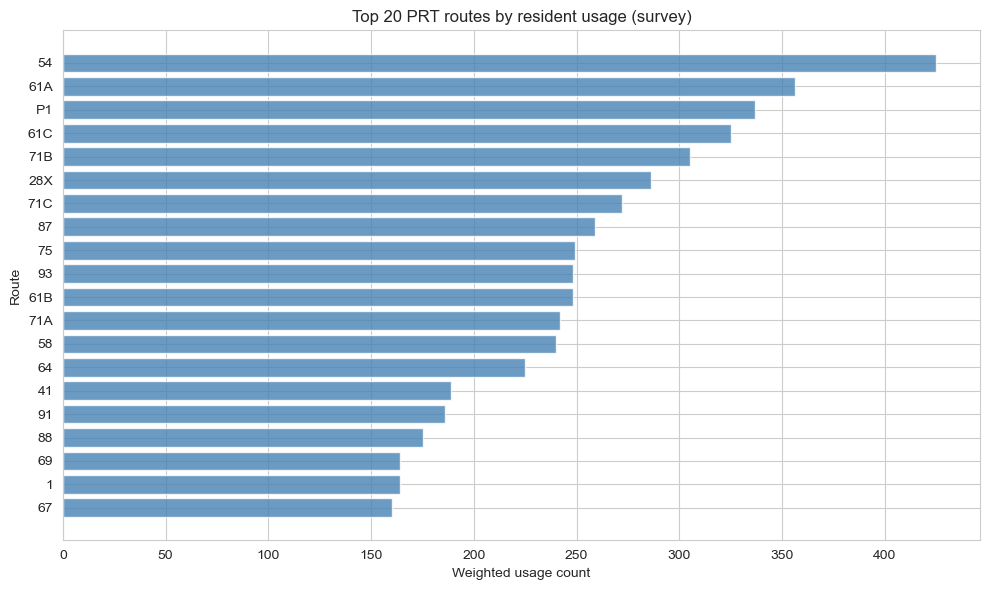

In [6]:
# Visualize top routes
top_n = 20
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(route_df["route"].head(top_n)[::-1], route_df["weighted_count"].head(top_n)[::-1], color="steelblue", alpha=0.8)
ax.set_xlabel("Weighted usage count")
ax.set_ylabel("Route")
ax.set_title("Top 20 PRT routes by resident usage (survey)")
plt.tight_layout()
plt.show()

## 4. Impact Scores — Who Is Hurt vs. Helped by Proposed Changes?

In [7]:
# Composite impact: average of the three 1–5 scales (lower = more positive)
df["impact_avg"] = df[["impact_peak_reduction", "impact_direct_services", "impact_offpeak"]].mean(axis=1)

# Classify sentiment: 1–2 positive, 3 neutral, 4–5 negative
def impact_sentiment(avg):
    if pd.isna(avg):
        return "no_response"
    if avg <= 2:
        return "positive"
    if avg < 4:
        return "neutral"
    return "negative"

df["impact_sentiment"] = df["impact_avg"].apply(impact_sentiment)
print("Impact sentiment distribution:")
print(df["impact_sentiment"].value_counts())
print("\nMean impact (1=best, 5=worst):", df["impact_avg"].mean())

Impact sentiment distribution:
impact_sentiment
negative       659
neutral        591
positive       346
no_response    140
Name: count, dtype: int64

Mean impact (1=best, 5=worst): 3.3685149688450293


In [8]:
# Impact by route (for respondents who gave a rating and listed that route as #1)
df_with_impact = df.dropna(subset=["impact_avg", "route_1"])
route_impact = df_with_impact.groupby("route_1").agg(
    count=("impact_avg", "count"),
    mean_impact=("impact_avg", "mean"),
    pct_negative=("impact_sentiment", lambda s: (s == "negative").mean() * 100),
).round(2)
route_impact = route_impact[route_impact["count"] >= 5].sort_values("mean_impact", ascending=False)
print("Routes with highest mean impact (most negative = most concern). Min 5 respondents:")
display(route_impact.head(20))

Routes with highest mean impact (most negative = most concern). Min 5 respondents:


,count,mean_impact,pct_negative
route_1,,,
P16,19,4.66,94.74
22,20,4.51,85.00
P12,6,4.50,100.00
O5,11,4.42,81.82
Y45,20,4.36,75.00
56,16,4.34,68.75
G3,11,4.32,72.73
52L,19,4.31,78.95
P10,17,4.29,82.35


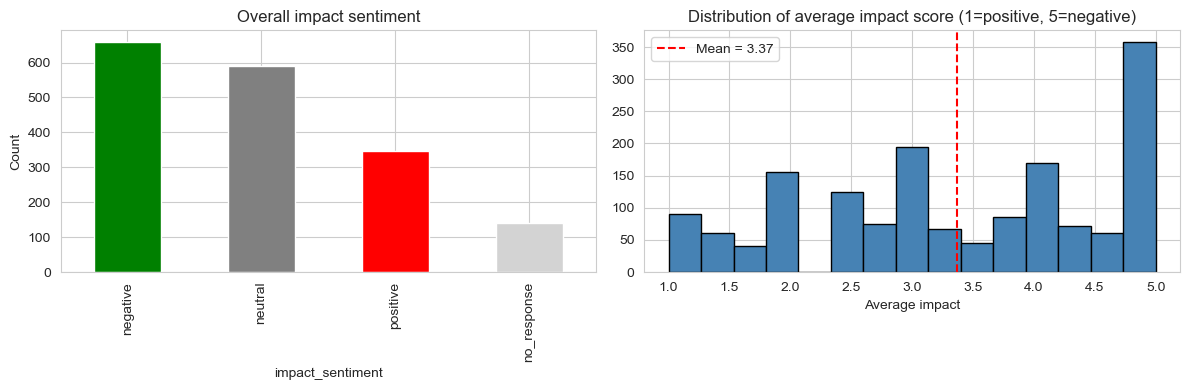

In [9]:
# Distribution of impact sentiment
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["impact_sentiment"].value_counts().plot(kind="bar", ax=axes[0], color=["green", "gray", "red", "lightgray"])
axes[0].set_title("Overall impact sentiment")
axes[0].set_ylabel("Count")

df["impact_avg"].dropna().hist(bins=15, ax=axes[1], color="steelblue", edgecolor="black")
axes[1].axvline(df["impact_avg"].mean(), color="red", linestyle="--", label=f"Mean = {df['impact_avg'].mean():.2f}")
axes[1].set_title("Distribution of average impact score (1=positive, 5=negative)")
axes[1].set_xlabel("Average impact")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Demographics and Impact

In [10]:
# Impact by age (among those who answered impact)
age_impact = df.dropna(subset=["impact_avg", "age"]).groupby("age")["impact_avg"].agg(["mean", "count"])
age_impact = age_impact[age_impact["count"] >= 10].sort_values("mean")
print("Mean impact by age (higher = more negative):")
display(age_impact)

Mean impact by age (higher = more negative):


,mean,count
age,,
16-19 years old,2.733333,35
20-24 years old,3.022676,147
25-44 years old,3.288781,823
45-54 years old,3.327320,194
60+,3.698450,215
55-59 years old,3.848797,97


In [11]:
# Last trip recency vs impact (recent riders may have stronger opinions)
df_valid = df.dropna(subset=["impact_avg", "last_trip"])
trip_order = ["Today", "In the past week", "In the past month", "In the past year",
              "Not since before the COVID 19 pandemic started (March 2020)", "Never"]
df_valid["last_trip_ord"] = df_valid["last_trip"].astype("category").cat.set_categories(trip_order, ordered=True)
recency_impact = df_valid.groupby("last_trip", sort=False)["impact_avg"].agg(["mean", "count"])
print("Mean impact by last trip recency:")
display(recency_impact)

Mean impact by last trip recency:


/var/folders/gr/q3b533fd0n9fm5kktc5gq7wr0000gn/T/ipykernel_19857/2649272682.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["last_trip_ord"] = df_valid["last_trip"].astype("category").cat.set_categories(trip_order, ordered=True)


,mean,count
last_trip,,
In the past week,3.177305,470
Today,3.573542,800
In the past month,3.119883,171
In the past year,3.142029,115
Not since before the COVID 19 pandemic started (March 2020),3.186275,34
Never,3.500000,5


## 6. Text Feedback — Reasons for Negative vs Positive Impact

In [12]:
# Count non-empty text responses
text_cols = ["reason_positive", "reason_negative", "excited_route", "additional_comments"]
for c in text_cols:
    n = df[c].notna().sum()
    n_nonempty = df[c].astype(str).str.strip().replace("", np.nan).notna().sum()
    print(f"{c}: {n_nonempty} non-empty / {len(df)} total")

reason_positive: 1736 non-empty / 1736 total
reason_negative: 1736 non-empty / 1736 total
excited_route: 1736 non-empty / 1736 total
additional_comments: 1736 non-empty / 1736 total


In [13]:
# Extract common phrases from negative reasons (simple word frequency)
def get_words(series, stop_extra=None):
    stop = {"the", "a", "an", "and", "or", "but", "to", "of", "in", "on", "for", "with", "is", "are", "will", "be", "my", "i", "it", "that", "this", "would", "have", "has", "not", "no", "other", "nan"}
    if stop_extra:
        stop.update(stop_extra)
    all_words = []
    for x in series.dropna():
        s = re.sub(r"[^a-zA-Z0-9\s]", " ", str(x).lower())
        words = [w for w in s.split() if len(w) > 2 and w not in stop]
        all_words.extend(words)
    return pd.Series(all_words).value_counts()

neg_words = get_words(df["reason_negative"], stop_extra={"think", "bus", "buses", "route", "routes"})
print("Top 20 words in 'reason for negative impact':")
print(neg_words.head(20))

Top 20 words in 'reason for negative impact':
more           438
slower         418
transfers      347
require        345
trip           343
less           299
frequently     286
arrive         285
trips           79
from            78
looks           67
downtown        66
stop            65
harder          65
complicated     63
network         63
understand      62
work            62
get             58
service         45
Name: count, dtype: int64


In [14]:
# Route mentions in negative feedback (which routes people complain about)
def extract_route_mentions(series):
    # Match common route patterns: numbers, P/O/G/Y/N/D + number, e.g. 54, 28X, P71, O47
    pattern = r"\b(\d+[A-Z]?|[POGYND]\d+[A-Z]?)\b"
    mentions = {}
    for x in series.dropna():
        s = str(x).upper()
        for m in re.finditer(pattern, s, re.IGNORECASE):
            r = m.group(1).upper()
            mentions[r] = mentions.get(r, 0) + 1
    return pd.Series(mentions).sort_values(ascending=False)

neg_route_mentions = extract_route_mentions(df["reason_negative"])
print("Routes mentioned in negative impact reasons (top 20):")
print(neg_route_mentions.head(20))

Routes mentioned in negative impact reasons (top 20):
4      9
1      9
2      8
30     8
27     7
54     7
20     5
31     5
93     5
Y45    5
75     5
7      4
15     4
58     4
5      4
40     4
3      4
45     3
26     3
77     3
dtype: int64


In [15]:
# Routes people are excited about (from "excited_route" and "reason_positive")
excited_text = df["excited_route"].fillna("").astype(str) + " " + df["reason_positive"].fillna("").astype(str)
excited_mentions = extract_route_mentions(excited_text)
print("Routes mentioned in positive/excited feedback (top 15):")
print(excited_mentions.head(15))

Routes mentioned in positive/excited feedback (top 15):
28X    45
64     39
41     19
N37    16
87     16
69     14
54     14
P1     13
D62    13
N94    13
30     10
O47     9
1       8
20      8
D87     8
dtype: int64


## 7. Route-Level Recommendations (Add / Eliminate / Change)

In [16]:
# Build route-level summary: usage, mean impact, negative %, mentions in negative text
route_impact_reset = route_impact.reset_index().rename(
    columns={"mean_impact": "mean_impact_1st", "count": "n_respondents_1st"}
)
route_summary = route_df.merge(
    route_impact_reset,
    left_on="route",
    right_on="route_1",
    how="left",
).drop(columns=["route_1"], errors="ignore")
route_summary["mentions_in_negative"] = route_summary["route"].map(
    lambda r: neg_route_mentions.get(str(r).upper(), 0)
)
route_summary["mentions_in_positive"] = route_summary["route"].map(
    lambda r: excited_mentions.get(str(r).upper(), 0)
)
route_summary = route_summary.fillna(0)
route_summary["mean_impact_1st"] = route_summary["mean_impact_1st"].fillna(0)

# Risk: high use + high negative impact + negative mentions = reconsider eliminating
route_summary["risk_score"] = (
    route_summary["weighted_count"] * route_summary["mean_impact_1st"] +
    route_summary["mentions_in_negative"] * 2
)
route_summary = route_summary.sort_values("risk_score", ascending=False)
print("Route risk score (high usage × negative impact + negative mentions). Top 15 to reconsider eliminating:")
display(route_summary.head(15))

Route risk score (high usage × negative impact + negative mentions). Top 15 to reconsider eliminating:


,route,weighted_count,n_respondents_1st,mean_impact_1st,pct_negative,mentions_in_negative,mentions_in_positive,risk_score
0,54,425,81.0,3.33,40.74,7,14,1429.25
2,P1,337,46.0,2.81,10.87,2,13,950.97
12,58,240,56.0,3.91,58.93,4,7,946.40
3,61C,325,37.0,2.91,24.32,0,2,945.75
1,61A,356,52.0,2.61,17.31,0,4,929.16
7,87,259,47.0,3.54,42.55,2,16,920.86
5,28X,286,43.0,3.14,30.23,3,45,904.04
4,71B,305,57.0,2.82,19.30,0,3,860.10
9,93,248,44.0,3.38,38.64,5,7,848.24
6,71C,272,36.0,2.94,25.00,1,6,801.68


## 8. Machine Learning — Predicting Impact Sentiment

In [17]:
# Prepare ML dataset: predict impact_sentiment from demographics + route_1 + last_trip
ml_df = df.dropna(subset=["impact_sentiment"]).copy()
ml_df = ml_df[ml_df["impact_sentiment"] != "no_response"]

# Features: categorical (encoded) + optional text
features_cat = ["route_1", "last_trip", "age", "gender", "income"]
ml_df = ml_df.dropna(subset=features_cat)
X_cat = ml_df[features_cat].astype(str)
y = ml_df["impact_sentiment"]

# Encode target and features
le_y = LabelEncoder()
y_enc = le_y.fit_transform(y)
encoders = {c: LabelEncoder().fit(X_cat[c]) for c in features_cat}
X_enc = pd.DataFrame({c: encoders[c].transform(X_cat[c]) for c in features_cat}, index=X_cat.index)

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y_enc, test_size=0.25, random_state=42, stratify=y_enc
)
print("Train size:", len(X_train), "Test size:", len(X_test))
print("Classes:", le_y.classes_)

Train size: 1011 Test size: 337
Classes: ['negative' 'neutral' 'positive']


In [18]:
# Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le_y.classes_))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.50      0.59      0.54       135
     neutral       0.44      0.49      0.47       128
    positive       0.31      0.15      0.20        74

    accuracy                           0.45       337
   macro avg       0.42      0.41      0.40       337
weighted avg       0.43      0.45      0.44       337

Confusion matrix:
[[79 44 12]
 [52 63 13]
 [28 35 11]]


Feature importance for predicting impact sentiment:


,feature,importance
0,route_1,0.463089
4,income,0.187099
2,age,0.154633
1,last_trip,0.110380
3,gender,0.084799


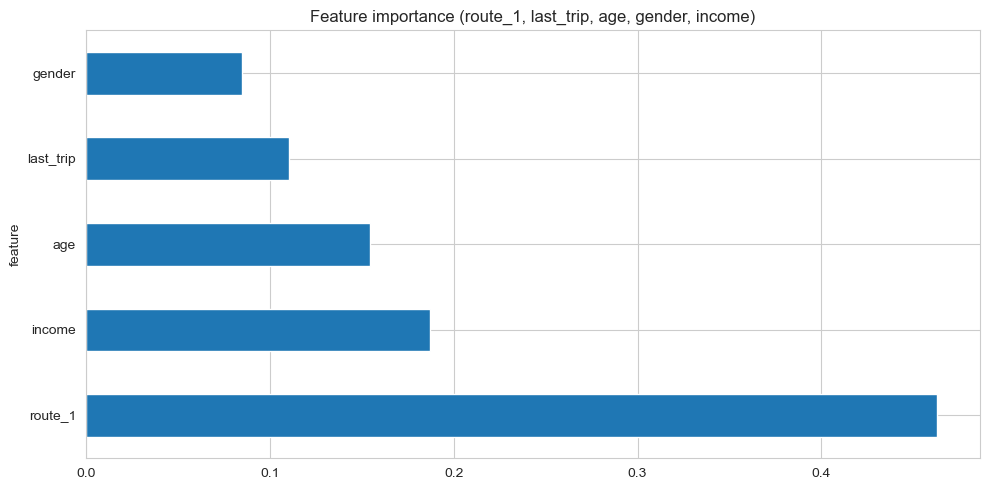

In [19]:
# Feature importance (which factors most predict positive vs negative?)
imp = pd.DataFrame({
    "feature": features_cat,
    "importance": clf.feature_importances_,
}).sort_values("importance", ascending=False)
print("Feature importance for predicting impact sentiment:")
display(imp)
imp.plot(x="feature", y="importance", kind="barh", legend=False)
plt.title("Feature importance (route_1, last_trip, age, gender, income)")
plt.tight_layout()
plt.show()

## 9. Text-Based Sentiment (TF-IDF + Classifier)

In [20]:
# Use negative + additional_comments as text; predict binary negative vs non-negative
df_text = df.dropna(subset=["impact_sentiment"]).copy()
df_text = df_text[df_text["impact_sentiment"].isin(["positive", "neutral", "negative"])]
df_text["text"] = (
    df_text["reason_negative"].fillna("").astype(str) + " " +
    df_text["additional_comments"].fillna("").astype(str)
)
df_text = df_text[df_text["text"].str.strip().str.len() >= 20]  # enough text
df_text["is_negative"] = (df_text["impact_sentiment"] == "negative").astype(int)

X_t = df_text["text"]
y_t = df_text["is_negative"]
X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(
    X_t, y_t, test_size=0.25, random_state=42, stratify=y_t
)

vec = TfidfVectorizer(max_features=500, stop_words="english", ngram_range=(1, 2))
X_train_tf = vec.fit_transform(X_t_train)
X_test_tf = vec.transform(X_t_test)

clf_t = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
clf_t.fit(X_train_tf, y_t_train)
y_t_pred = clf_t.predict(X_test_tf)
print("Binary classification (negative vs non-negative) from text:")
print(classification_report(y_t_test, y_t_pred, target_names=["non_negative", "negative"]))

Binary classification (negative vs non-negative) from text:
              precision    recall  f1-score   support

non_negative       0.67      0.73      0.70       162
    negative       0.70      0.63      0.66       160

    accuracy                           0.68       322
   macro avg       0.68      0.68      0.68       322
weighted avg       0.68      0.68      0.68       322



In [21]:
# Top TF-IDF terms associated with negative predictions
names = vec.get_feature_names_out()
imps = clf_t.feature_importances_
idx = np.argsort(imps)[::-1][:25]
print("Top 25 text features (TF-IDF) for predicting negative sentiment:")
for i in idx:
    print(f"  {names[i]}: {imps[i]:.4f}")

Top 25 text features (TF-IDF) for predicting negative sentiment:
  bus: 0.0293
  slower require: 0.0210
  work: 0.0188
  trip slower: 0.0187
  trip: 0.0184
  slower: 0.0181
  transfers: 0.0180
  think: 0.0176
  require: 0.0151
  completely: 0.0147
  think trip: 0.0143
  route: 0.0135
  require transfers: 0.0128
  routes: 0.0126
  buses: 0.0125
  downtown: 0.0120
  oakland: 0.0117
  stop: 0.0106
  arrive: 0.0098
  bus stop: 0.0095
  neighborhood: 0.0091
  service: 0.0084
  stops: 0.0082
  discontinued: 0.0081
  area: 0.0081


## 10. Summary and Recommendations

In [22]:
# Summary statistics for report
n_total = len(df)
n_with_impact = df["impact_avg"].notna().sum()
n_negative = (df["impact_sentiment"] == "negative").sum()
n_positive = (df["impact_sentiment"] == "positive").sum()

print("=== PRT FEEDBACK ANALYSIS SUMMARY ===\n")
print(f"Total responses: {n_total}")
print(f"With impact rating: {n_with_impact}")
print(f"Negative sentiment: {n_negative} ({100*n_negative/n_with_impact:.1f}%)")
print(f"Positive sentiment: {n_positive} ({100*n_positive/n_with_impact:.1f}%)")
print(f"\nMean impact score (1=positive, 5=negative): {df['impact_avg'].mean():.2f}")
print("\n--- ROUTES TO RECONSIDER ELIMINATING (high use + high negative impact) ---")
cols = ["route", "weighted_count", "mean_impact_1st", "mentions_in_negative"]
if "pct_negative" in route_summary.columns:
    cols.insert(3, "pct_negative")
print(route_summary.head(10)[cols].to_string())
print("\n--- ROUTES RESIDENTS ARE EXCITED ABOUT (add/expand) ---")
print(excited_mentions.head(10).to_string())

=== PRT FEEDBACK ANALYSIS SUMMARY ===

Total responses: 1736
With impact rating: 1596
Negative sentiment: 659 (41.3%)
Positive sentiment: 346 (21.7%)

Mean impact score (1=positive, 5=negative): 3.37

--- ROUTES TO RECONSIDER ELIMINATING (high use + high negative impact) ---
   route  weighted_count  mean_impact_1st  pct_negative  mentions_in_negative
0     54             425             3.33         40.74                     7
2     P1             337             2.81         10.87                     2
12    58             240             3.91         58.93                     4
3    61C             325             2.91         24.32                     0
1    61A             356             2.61         17.31                     0
7     87             259             3.54         42.55                     2
5    28X             286             3.14         30.23                     3
4    71B             305             2.82         19.30                     0
9     93             2

### Recommendations

1. **Eliminate or reduce with caution:** Routes that rank high on *risk_score* (high weighted usage and high mean negative impact, or many mentions in negative feedback) should be reconsidered before elimination. Use the *route_summary* and *neg_route_mentions* tables to identify them (e.g. 54, 28X, 61-series, 71-series, 93, 88, 67).

2. **Add or expand:** Routes and corridors that appear in *excited_route* and *reason_positive* (e.g. South Hills–Oakland direct, O47, N84, new crosstown links) align with resident demand.

3. **Change, don’t cut:** Where elimination is planned, check negative reasons: “slower/more transfers,” “less frequent,” “bus stop no longer near.” Consider route modifications (e.g. keep key segments, add stops) instead of full removal.

4. **Demographics:** ML feature importance suggests *route_1* and *last_trip* are strong predictors of impact sentiment; recent riders and specific route users are key stakeholders.

5. **Text themes:** TF-IDF + RF show which phrases correlate with negative sentiment; use them to tag and prioritize open-ended feedback for route-specific changes.

## 11. Modeling Upgrade (Professor-Friendly): Pipelines + Cross-Validation

In [ ]:
# Use a proper sklearn Pipeline with OneHotEncoder (better than LabelEncoder for categorical features)
model_df = df.copy()
model_df = model_df[model_df["impact_sentiment"].isin(["positive", "neutral", "negative"])].copy()

features = ["route_1", "last_trip", "age", "gender", "income"]
model_df = model_df.dropna(subset=features + ["impact_sentiment"])

X = model_df[features]
y = model_df["impact_sentiment"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features),
    ],
    remainder="drop",
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "logreg": LogisticRegression(max_iter=2000, n_jobs=None),
    "rf": RandomForestClassifier(n_estimators=300, random_state=42),
    "hgb": HistGradientBoostingClassifier(random_state=42),
}

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
}

results = []
for name, m in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", m)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=None)
    results.append({
        "model": name,
        "acc_mean": scores["test_accuracy"].mean(),
        "acc_std": scores["test_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
        "n": len(X),
    })

cv_results = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)
cv_results

In [ ]:
# Fit the best-performing model on all data (by macro-F1) to generate route-level burden scores
best_name = cv_results.iloc[0]["model"]
best_model = models[best_name]

best_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", best_model)])
best_pipe.fit(X, y)

# Predicted probability of "negative" (if model supports predict_proba)
if hasattr(best_pipe.named_steps["model"], "predict_proba"):
    proba = best_pipe.predict_proba(X)
    neg_idx = list(best_pipe.named_steps["model"].classes_).index("negative")
    p_negative = proba[:, neg_idx]
else:
    # fallback: use predicted label as 0/1 proxy
    p_negative = (best_pipe.predict(X) == "negative").astype(float)

model_df = model_df.assign(p_negative=p_negative)

# Route burden: average predicted negative probability among riders of that primary route
route_burden = model_df.groupby("route_1").agg(
    n=("p_negative", "count"),
    avg_p_negative=("p_negative", "mean"),
    obs_pct_negative=("impact_sentiment", lambda s: (s == "negative").mean()),
).sort_values(["avg_p_negative", "n"], ascending=[False, False])

route_burden = route_burden[route_burden["n"] >= 10]
route_burden.head(20)

In [ ]:
# Permutation importance for interpretability (top drivers of sentiment)
# Note: importance is computed on the full dataset, so treat as directional insight.

# We compute importance on a sample for speed if needed.
X_sample = X.copy()
y_sample = y.copy()

perm = permutation_importance(
    best_pipe,
    X_sample,
    y_sample,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
)

# Aggregate importance back to original feature groups (OneHotEncoder expands many columns)
# We'll report total importance per original feature (route_1, last_trip, ...)
feature_names = best_pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(features)
imp_df = pd.DataFrame({
    "encoded_feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
})
imp_df["base_feature"] = imp_df["encoded_feature"].str.split("_").str[0]
base_imp = imp_df.groupby("base_feature")["importance_mean"].sum().sort_values(ascending=False)
base_imp

## 12. Topic Modeling (NMF) on Open-Ended Feedback

In [ ]:
# Build a corpus from open-ended feedback and discover themes using NMF
text_df = df.copy()
text_df["text_all"] = (
    text_df["reason_negative"].fillna("").astype(str) + " " +
    text_df["reason_positive"].fillna("").astype(str) + " " +
    text_df["excited_route"].fillna("").astype(str) + " " +
    text_df["additional_comments"].fillna("").astype(str)
).str.replace(r"\s+", " ", regex=True).str.strip()

text_df = text_df[text_df["text_all"].str.len() >= 30].copy()

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=2000,
    ngram_range=(1, 2),
    min_df=5,
)
X_tfidf = vectorizer.fit_transform(text_df["text_all"])

n_topics = 8
nmf = NMF(n_components=n_topics, random_state=42, init="nndsvda", max_iter=400)
W = nmf.fit_transform(X_tfidf)
H = nmf.components_
terms = np.array(vectorizer.get_feature_names_out())

def top_terms_for_topic(topic_idx, top_k=12):
    top_idx = np.argsort(H[topic_idx])[::-1][:top_k]
    return terms[top_idx]

topics = []
for k in range(n_topics):
    topics.append({
        "topic": k,
        "top_terms": ", ".join(top_terms_for_topic(k, 12)),
    })

topic_table = pd.DataFrame(topics)
topic_table

In [ ]:
# Assign each comment to its dominant topic, then see which routes are associated with which topics
text_df["topic"] = W.argmax(axis=1)

# Show example comments per topic (quick qualitative validation)
for k in range(n_topics):
    print("\n=== Topic", k, "===")
    print("Top terms:", topic_table.loc[topic_table["topic"] == k, "top_terms"].iloc[0])
    examples = text_df[text_df["topic"] == k]["text_all"].head(3).tolist()
    for i, ex in enumerate(examples, 1):
        print(f"  Example {i}:", ex[:300], "...")

# Route-topic association (using primary route)
rt = text_df.dropna(subset=["route_1"]).groupby(["route_1", "topic"]).size().reset_index(name="n")
rt_total = rt.groupby("route_1")["n"].sum().reset_index(name="n_total")
rt = rt.merge(rt_total, on="route_1")
rt["pct"] = (rt["n"] / rt["n_total"]) * 100

# For each topic, top routes by count
for k in range(n_topics):
    top_routes = rt[rt["topic"] == k].sort_values("n", ascending=False).head(10)
    print(f"\nTop routes in Topic {k}:")
    display(top_routes[["route_1", "n", "pct", "n_total"]])

## 13. Model-Driven Recommendations Table (Routes to Keep/Change/Add)

In [ ]:
# Combine: usage + observed impact + model burden + text negativity mentions

# Usage
usage = route_df.copy()

# Observed impact by route_1
obs = df.dropna(subset=["impact_avg", "route_1"]).groupby("route_1").agg(
    n_obs=("impact_avg", "count"),
    mean_impact_obs=("impact_avg", "mean"),
    pct_negative_obs=("impact_sentiment", lambda s: (s == "negative").mean() * 100),
).reset_index().rename(columns={"route_1": "route"})

# Model burden
burden = route_burden.reset_index().rename(columns={"route_1": "route"})

# Text mentions
mentions = pd.DataFrame({
    "route": usage["route"],
    "mentions_in_negative": usage["route"].map(lambda r: neg_route_mentions.get(str(r).upper(), 0)),
    "mentions_in_positive": usage["route"].map(lambda r: excited_mentions.get(str(r).upper(), 0)),
})

rec = usage.merge(obs, on="route", how="left") \
          .merge(burden[["route", "avg_p_negative", "n"]].rename(columns={"n": "n_model"}), on="route", how="left") \
          .merge(mentions, on="route", how="left")

rec = rec.fillna(0)

# A more defensible composite score:
# - strong use -> higher weight
# - high predicted negative burden -> higher
# - many negative mentions -> higher
rec["keep_change_priority"] = (
    rec["weighted_count"] * (1 + rec["avg_p_negative"]) +
    2 * rec["mentions_in_negative"]
)

# Candidates for 'ADD/EXPAND': lots of positive mentions + decent usage
rec["add_expand_priority"] = (
    3 * rec["mentions_in_positive"] + 0.5 * rec["weighted_count"]
)

print("Top routes to KEEP/CHANGE carefully (high use + high modeled negative burden + complaints):")
display(rec.sort_values("keep_change_priority", ascending=False).head(20)[
    ["route", "weighted_count", "avg_p_negative", "n_model", "mean_impact_obs", "pct_negative_obs", "mentions_in_negative", "keep_change_priority"]
])

print("\nTop routes/corridors to ADD/EXPAND (based on excited mentions + usage):")
display(rec.sort_values("add_expand_priority", ascending=False).head(20)[
    ["route", "mentions_in_positive", "weighted_count", "add_expand_priority"]
])